# **Histogram**


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-14 08:29:07--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  12.1MB/s    in 19s     

2026-03-14 08:29:28 (10.5 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name
FROM sqlite_master
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


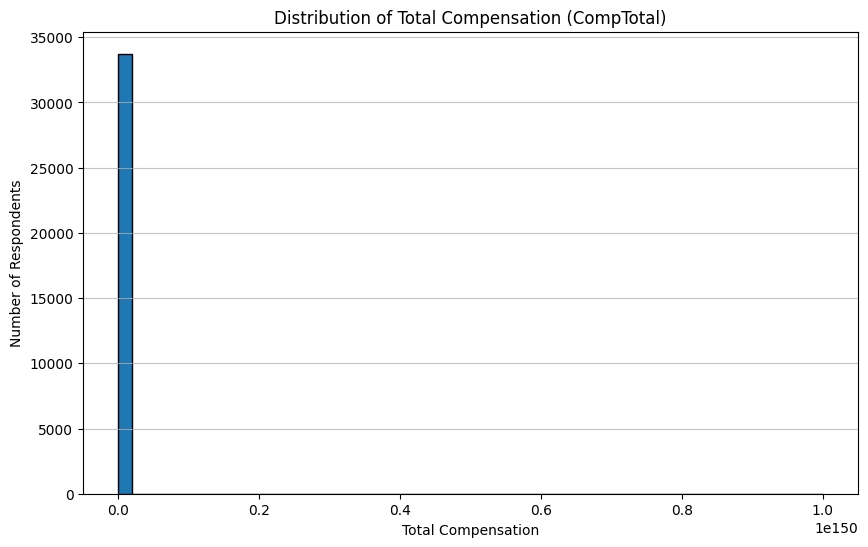

In [9]:
QUERY = "SELECT CompTotal FROM main"
df_comptotal = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric, coercing errors to NaN
df_comptotal['CompTotal'] = pd.to_numeric(df_comptotal['CompTotal'], errors='coerce')

# Drop NaN values if any
df_comptotal.dropna(subset=['CompTotal'], inplace=True)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df_comptotal['CompTotal'], bins=50, edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.75)
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


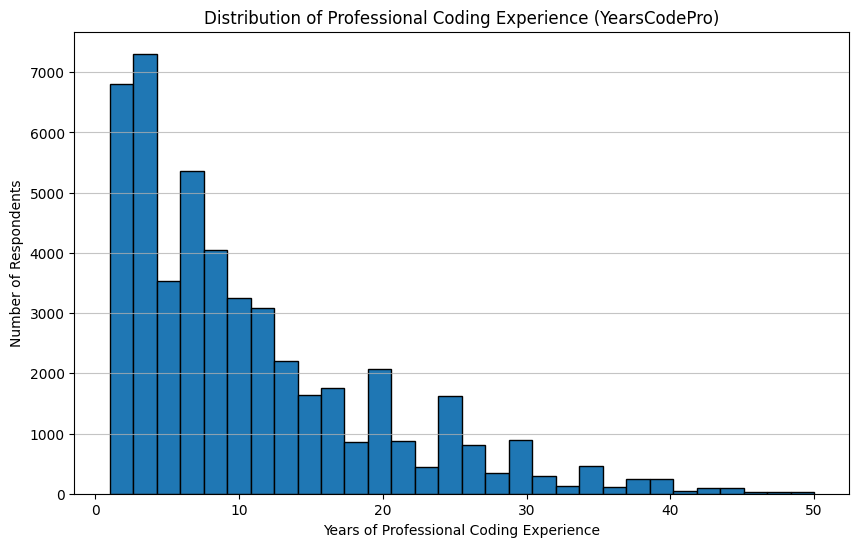

In [10]:
QUERY = "SELECT YearsCodePro FROM main"
df_yearscodepro = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric, coercing errors to NaN
df_yearscodepro['YearsCodePro'] = pd.to_numeric(df_yearscodepro['YearsCodePro'], errors='coerce')

# Drop NaN values if any
df_yearscodepro.dropna(subset=['YearsCodePro'], inplace=True)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df_yearscodepro['YearsCodePro'], bins=30, edgecolor='black')
plt.title('Distribution of Professional Coding Experience (YearsCodePro)')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


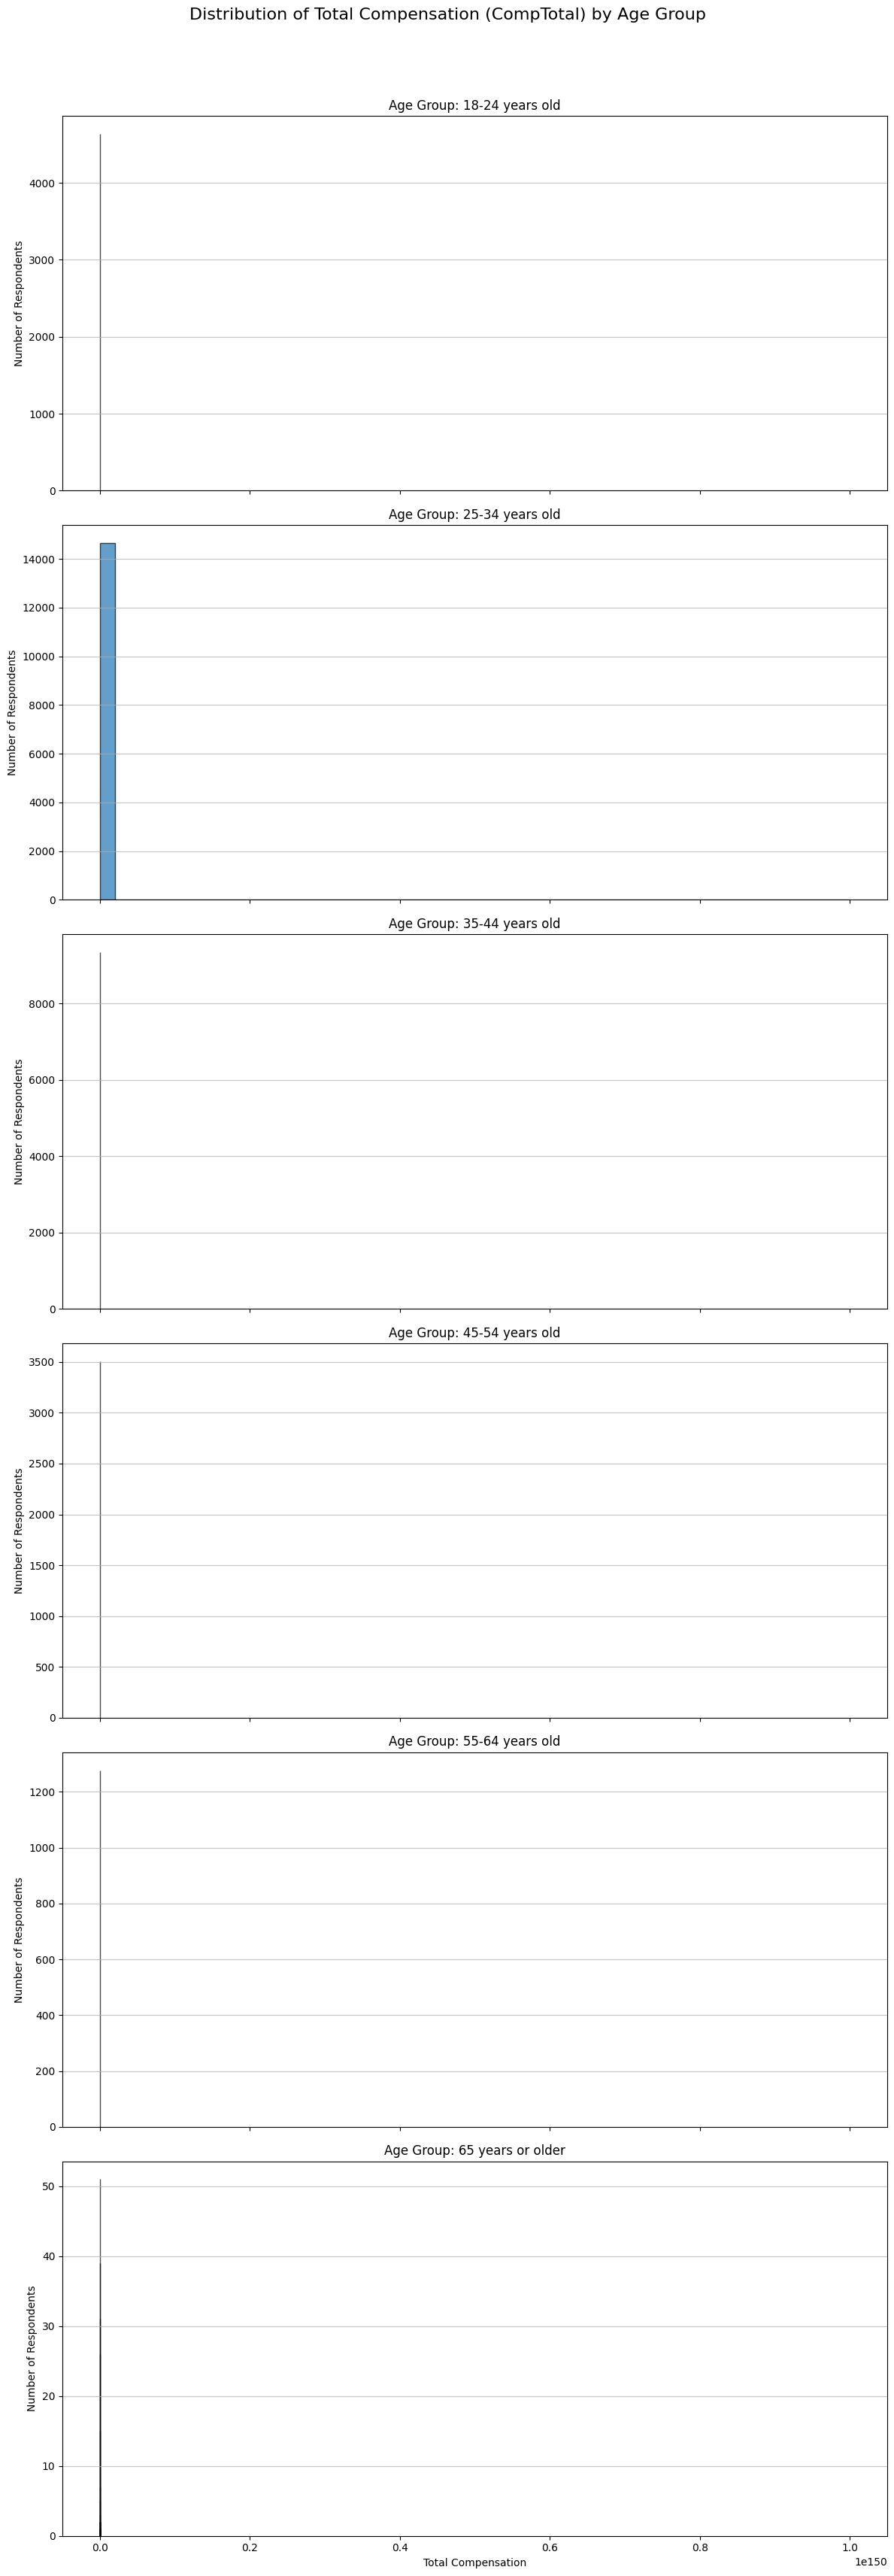

In [12]:
QUERY = "SELECT Age, CompTotal FROM main"
df_age_comptotal = pd.read_sql_query(QUERY, conn)

# Convert CompTotal to numeric, coercing errors to NaN
df_age_comptotal['CompTotal'] = pd.to_numeric(df_age_comptotal['CompTotal'], errors='coerce')

# Drop NaN values and rows where Age is 'Prefer not to say' or 'Under 18 years old' for better visualization
df_age_comptotal.dropna(subset=['CompTotal', 'Age'], inplace=True)
df_age_comptotal = df_age_comptotal[~df_age_comptotal['Age'].isin(['Prefer not to say', 'Under 18 years old'])]

# Get unique age groups and sort them for consistent plotting order
age_groups = df_age_comptotal['Age'].unique()
# Custom sort order to ensure 'years old' appears correctly
def custom_sort_key(age_str):
    if age_str == '65 years or older':
        return 65
    elif 'Under' in age_str:
        return 0
    else:
        return int(age_str.split('-')[0])

age_groups = sorted(age_groups, key=custom_sort_key)

# Plotting histograms for each age group
fig, axes = plt.subplots(len(age_groups), 1, figsize=(12, 6 * len(age_groups)), sharex=True)
fig.suptitle('Distribution of Total Compensation (CompTotal) by Age Group', fontsize=16)

for i, age_group in enumerate(age_groups):
    subset = df_age_comptotal[df_age_comptotal['Age'] == age_group]
    axes[i].hist(subset['CompTotal'], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Age Group: {age_group}')
    axes[i].set_ylabel('Number of Respondents')
    axes[i].grid(axis='y', alpha=0.75)

axes[-1].set_xlabel('Total Compensation')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


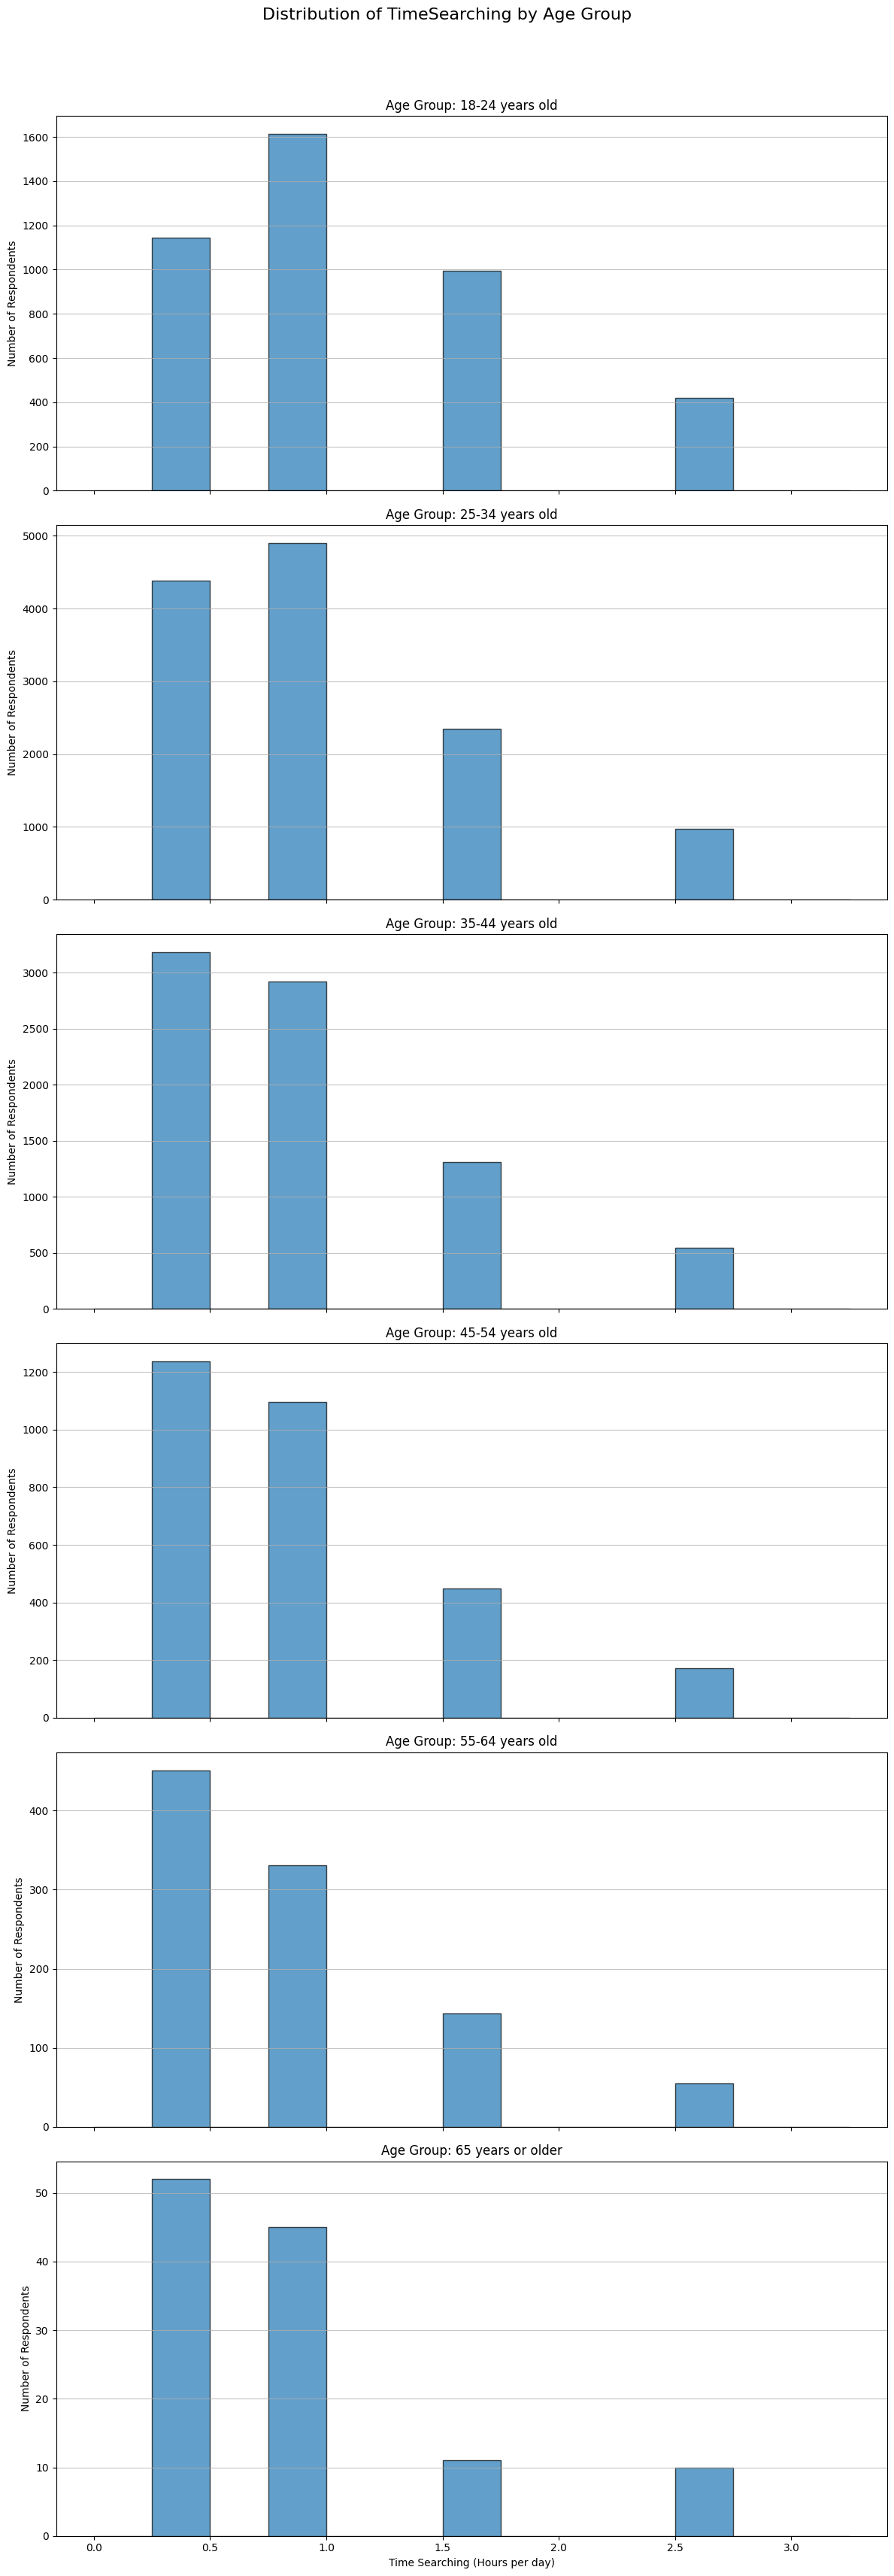

In [16]:
import numpy as np

QUERY = "SELECT Age, TimeSearching FROM main"
df_age_timesearching = pd.read_sql_query(QUERY, conn)

# Define a mapping for common TimeSearching categories to numerical values
# Based on the unique values identified: 'None', '30-60 minutes a day', '60-120 minutes a day', '15-30 minutes a day', 'Less than 15 minutes a day', 'Over 120 minutes a day'
time_search_mapping = {
    'Less than 15 minutes a day': 0.25, # Approximately 0.25 hours
    '15-30 minutes a day': 0.375,       # Approximately 0.375 hours (average of 15 and 30 minutes)
    '30-60 minutes a day': 0.75,        # Approximately 0.75 hours (average of 30 and 60 minutes)
    '60-120 minutes a day': 1.5,        # Approximately 1.5 hours (average of 60 and 120 minutes)
    'Over 120 minutes a day': 2.5       # A value slightly higher than 2 hours
    # 'None' will automatically become NaN when not in the map, which is desired.
}

# Apply the mapping to TimeSearching. Values not in the map will become NaN.
df_age_timesearching['TimeSearching'] = df_age_timesearching['TimeSearching'].map(time_search_mapping)

# Drop NaN values and rows where Age is 'Prefer not to say' or 'Under 18 years old' for better visualization
df_age_timesearching.dropna(subset=['TimeSearching', 'Age'], inplace=True)
df_age_timesearching = df_age_timesearching[~df_age_timesearching['Age'].isin(['Prefer not to say', 'Under 18 years old'])]

# Check if the DataFrame is empty after cleaning
if df_age_timesearching.empty:
    print("No valid numerical data for TimeSearching after cleaning and filtering age groups. Cannot plot histogram.")
else:
    # Get unique age groups and sort them for consistent plotting order
    age_groups_ts = df_age_timesearching['Age'].unique()
    # Reusing the custom_sort_key function defined earlier
    def custom_sort_key(age_str):
        if age_str == '65 years or older':
            return 65
        elif 'Under' in age_str:
            return 0
        else:
            # Extract the first number from the age string (e.g., '18-24' -> 18)
            return int(age_str.split('-')[0].split(' ')[0])

    age_groups_ts = sorted(age_groups_ts, key=custom_sort_key)

    # Plotting histograms for each age group
    fig, axes = plt.subplots(len(age_groups_ts), 1, figsize=(12, 6 * len(age_groups_ts)), sharex=True)
    fig.suptitle('Distribution of TimeSearching by Age Group', fontsize=16)

    # Define bins appropriate for the mapped numerical values (0 to 3 hours, covering the range 0.25 to 2.5)
    bins = np.arange(0, 3.5, 0.25) # Using 0.25 hour intervals

    for i, age_group in enumerate(age_groups_ts):
        subset = df_age_timesearching[df_age_timesearching['Age'] == age_group]
        axes[i].hist(subset['TimeSearching'], bins=bins, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Age Group: {age_group}')
        axes[i].set_ylabel('Number of Respondents')
        axes[i].grid(axis='y', alpha=0.75)

    axes[-1].set_xlabel('Time Searching (Hours per day)') # Changed to 'per day' as per typical interpretation of these categories
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


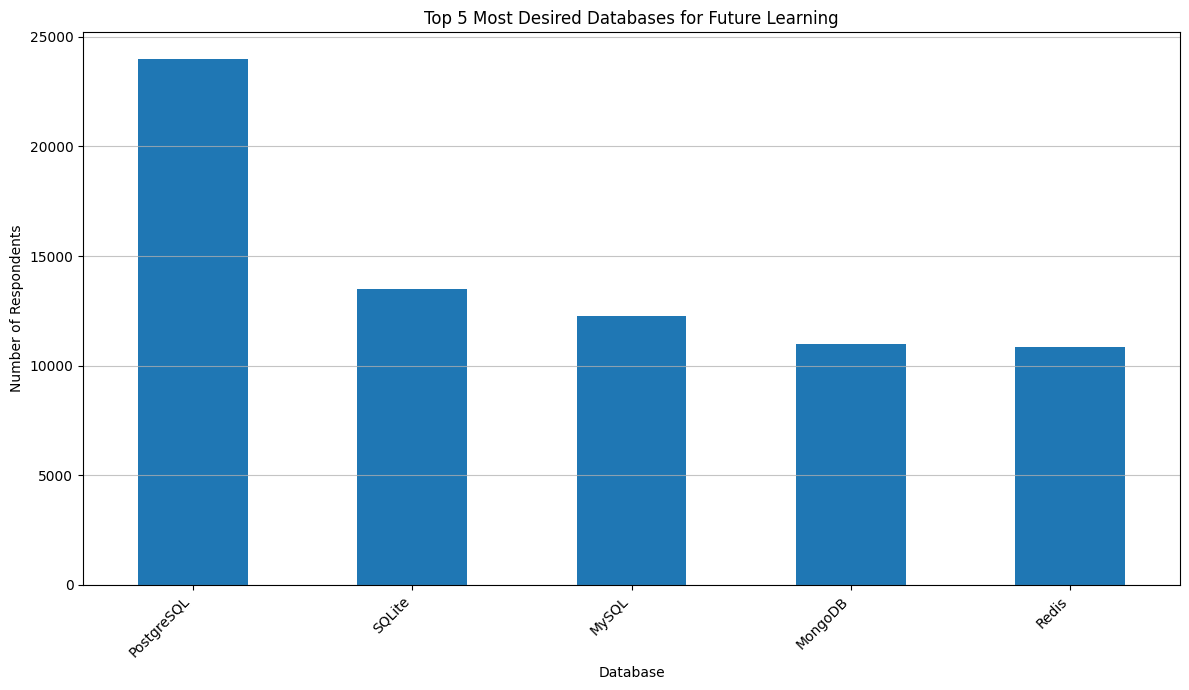

In [17]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main"
df_databases = pd.read_sql_query(QUERY, conn)

# Drop rows with NaN values in 'DatabaseWantToWorkWith'
df_databases.dropna(subset=['DatabaseWantToWorkWith'], inplace=True)

# Split the comma-separated strings into individual databases and count them
all_databases = df_databases['DatabaseWantToWorkWith'].str.split(';', expand=True).stack()
database_counts = all_databases.value_counts()

# Get the top 5 most desired databases
top_5_databases = database_counts.head(5)

# Plot histogram (bar chart)
plt.figure(figsize=(12, 7))
top_5_databases.plot(kind='bar')
plt.title('Top 5 Most Desired Databases for Future Learning')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


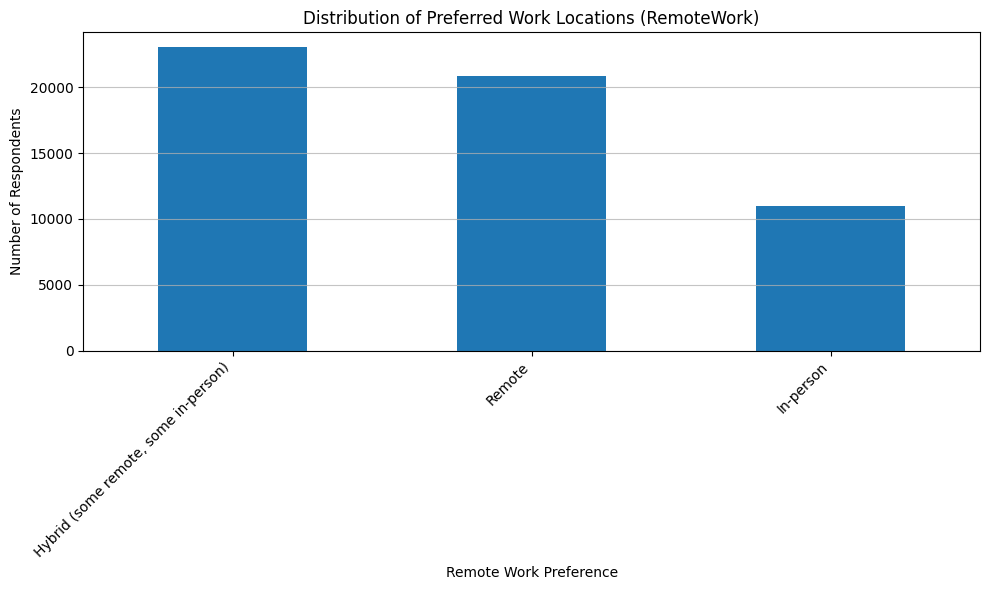

In [18]:
QUERY = "SELECT RemoteWork FROM main"
df_remotework = pd.read_sql_query(QUERY, conn)

# Count the occurrences of each RemoteWork category
remotework_counts = df_remotework['RemoteWork'].value_counts()

# Plot histogram (bar chart)
plt.figure(figsize=(10, 6))
remotework_counts.plot(kind='bar')
plt.title('Distribution of Preferred Work Locations (RemoteWork)')
plt.xlabel('Remote Work Preference')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


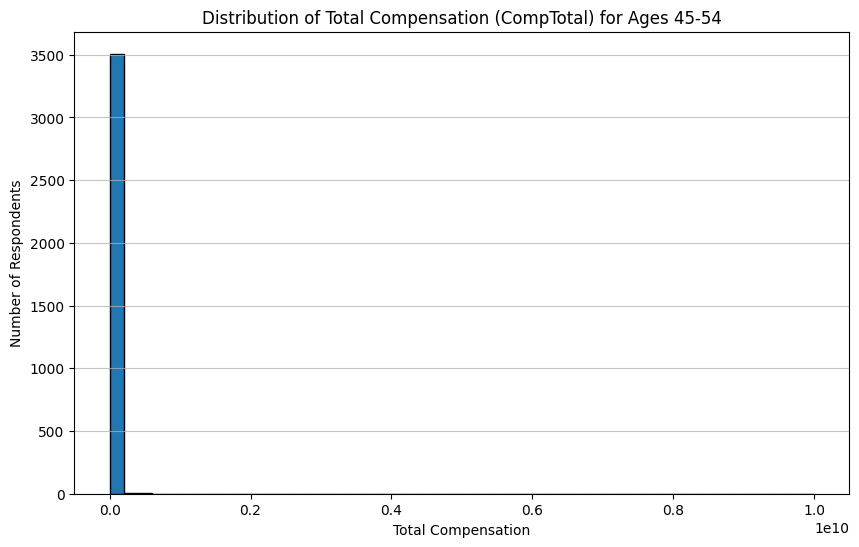

In [19]:
QUERY = "SELECT Age, CompTotal FROM main"
df_mid_career_comptotal = pd.read_sql_query(QUERY, conn)

# Filter for the age group 45-54 years old
df_mid_career_comptotal = df_mid_career_comptotal[df_mid_career_comptotal['Age'] == '45-54 years old']

# Convert CompTotal to numeric, coercing errors to NaN
df_mid_career_comptotal['CompTotal'] = pd.to_numeric(df_mid_career_comptotal['CompTotal'], errors='coerce')

# Drop NaN values if any
df_mid_career_comptotal.dropna(subset=['CompTotal'], inplace=True)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df_mid_career_comptotal['CompTotal'], bins=50, edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal) for Ages 45-54')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', alpha=0.75)
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


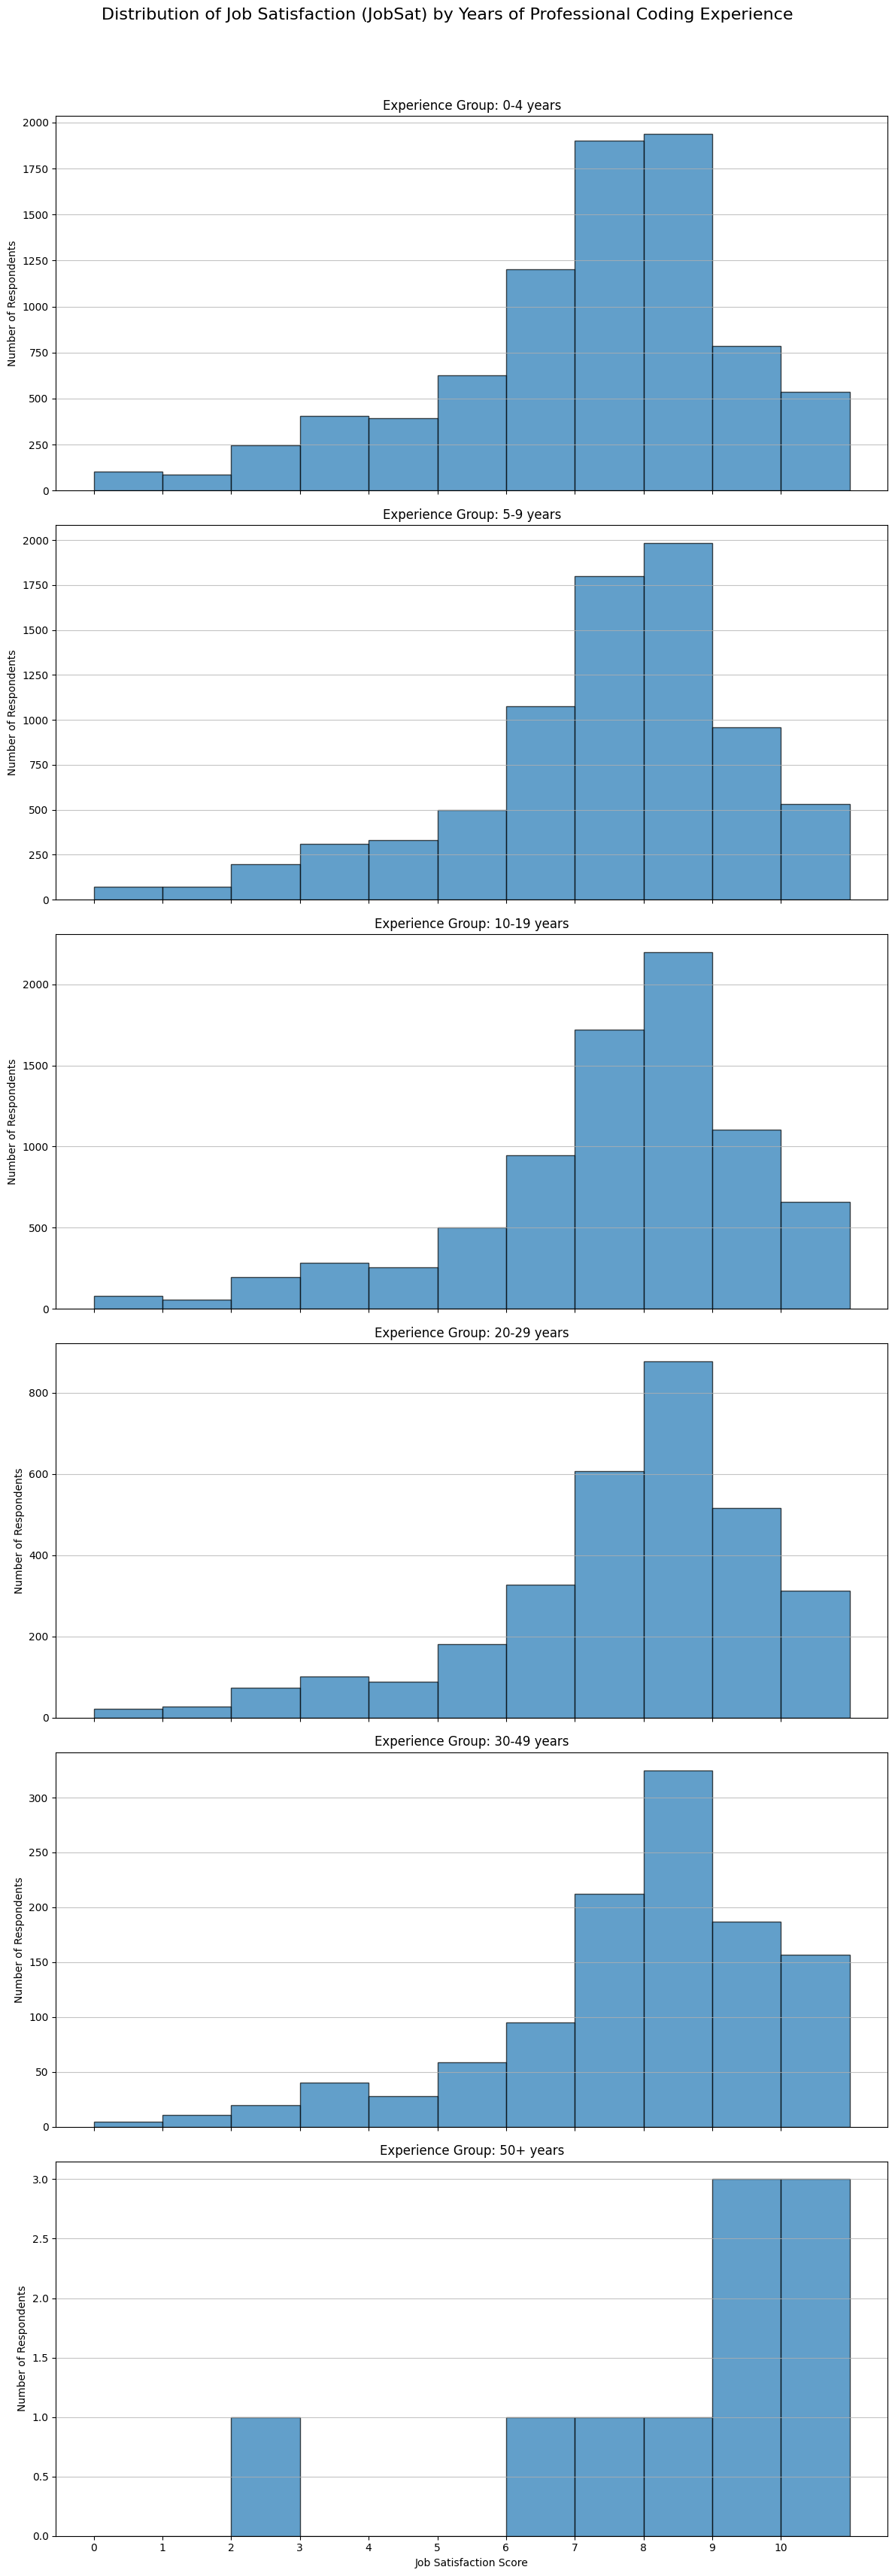

In [22]:
QUERY = "SELECT JobSat, YearsCodePro FROM main"
df_jobsat_yearscodepro = pd.read_sql_query(QUERY, conn)

# Handle 'YearsCodePro' string values first
def map_yearscodepro(value):
    if value == 'Less than 1 year':
        return 0.5  # Represent as 0.5 years
    elif value == 'More than 50 years':
        return 50.0 # Represent as 50 years or a high cap
    else:
        return pd.to_numeric(value, errors='coerce')

df_jobsat_yearscodepro['YearsCodePro'] = df_jobsat_yearscodepro['YearsCodePro'].apply(map_yearscodepro)

# JobSat appears to be numeric already (0-10), so no string mapping is needed.
# Convert JobSat to numeric directly, coercing errors to NaN if any non-numeric values exist.
df_jobsat_yearscodepro['JobSat'] = pd.to_numeric(df_jobsat_yearscodepro['JobSat'], errors='coerce')

# Drop NaN values if any in either column
df_jobsat_yearscodepro.dropna(subset=['JobSat', 'YearsCodePro'], inplace=True)

# Define bins for YearsCodePro to create experience groups
experience_bins = [0, 5, 10, 20, 30, 50, 60] # Example bins for years of experience
experience_labels = ['0-4 years', '5-9 years', '10-19 years', '20-29 years', '30-49 years', '50+ years']
df_jobsat_yearscodepro['ExperienceGroup'] = pd.cut(df_jobsat_yearscodepro['YearsCodePro'], bins=experience_bins, labels=experience_labels, right=False)

# Drop rows where ExperienceGroup is NaN (i.e., YearsCodePro fell outside defined bins)
df_jobsat_yearscodepro.dropna(subset=['ExperienceGroup'], inplace=True)

# Get unique experience groups for consistent plotting order
experience_groups = sorted(df_jobsat_yearscodepro['ExperienceGroup'].unique(), key=lambda x: experience_bins[experience_labels.index(x)])

if not experience_groups: # Check if experience_groups is empty
    print("No valid experience groups to plot after cleaning. DataFrame is empty.")
else:
    # Plotting histograms for JobSat by YearsCodePro group
    fig, axes = plt.subplots(len(experience_groups), 1, figsize=(12, 6 * len(experience_groups)), sharex=True)
    fig.suptitle('Distribution of Job Satisfaction (JobSat) by Years of Professional Coding Experience', fontsize=16)

    # Define bins for JobSat (assuming scores are 0-10 or similar, adjust if needed)
    # The previous unique values included 0-10, so let's set bins from 0 to 11.
    jobsat_bins = np.arange(0, 12, 1) # Bins for integer scores from 0 to 10

    for i, group in enumerate(experience_groups):
        subset = df_jobsat_yearscodepro[df_jobsat_yearscodepro['ExperienceGroup'] == group]
        axes[i].hist(subset['JobSat'], bins=jobsat_bins, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Experience Group: {group}')
        axes[i].set_ylabel('Number of Respondents')
        axes[i].set_xticks(np.arange(0, 11)) # Assuming scores 0-10
        axes[i].grid(axis='y', alpha=0.75)

    axes[-1].set_xlabel('Job Satisfaction Score')
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [23]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
